# Exploratory data analysis — 27-commodity panel

Statistical exploration of aligned daily prices and log-returns. No external narratives; outputs feed `data/market_events.csv` for downstream work.

In [1]:
# --- Paths & parameters (edit here) ---
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# notebook lives in results/ — data is one level up
DATA_DIR     = Path("..") / "data"
PRICES_PATH  = DATA_DIR / "prices.csv"
RETURNS_PATH = DATA_DIR / "returns.csv"
EVENTS_PATH  = DATA_DIR / "market_events.csv"

ROLLING_VOL_WINDOW     = 21
TRADING_DAYS_PER_YEAR  = 252
SIGMA_EVENT_THRESHOLD  = 3.0
VOL_SPIKE_RATIO        = 1.5
CORR_BREAK_THRESHOLD   = 0.35

SECTOR_MAP = {
    # Energy (8)
    "Brent":       "Energy",
    "WTI":         "Energy",
    "NaturalGas":  "Energy",
    "Gasoline":    "Energy",
    "Diesel":      "Energy",
    "HeatingOil":  "Energy",
    "ThermalCoal": "Energy",
    "Methanol":    "Energy",
    # Metals (10)
    "Gold":        "Metals",
    "Silver":      "Metals",
    "Copper":      "Metals",
    "Aluminium":   "Metals",
    "Nickel":      "Metals",
    "Zinc":        "Metals",
    "Platinum":    "Metals",
    "HRCSteel":    "Metals",
    "SGXIronOre":  "Metals",
    "Lithium":     "Metals",
    # Agriculture (9)
    "Coffee":      "Agriculture",
    "Corn":        "Agriculture",
    "Cotton":      "Agriculture",
    "LeanHogs":    "Agriculture",
    "LiveCattle":  "Agriculture",
    "Sugar":       "Agriculture",
    "Soybeans":    "Agriculture",
    "SoybeanOil":  "Agriculture",
    "HRWWheat":    "Agriculture",
}

SECTOR_ORDER = ["Energy", "Metals", "Agriculture"]
COMMODITIES  = list(SECTOR_MAP.keys())

def sector_sort_key(name):
    return (SECTOR_ORDER.index(SECTOR_MAP[name]), COMMODITIES.index(name))

COMMODITIES_ORDERED = sorted(COMMODITIES, key=sector_sort_key)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

In [2]:
# --- Load panels ---
prices    = pd.read_csv(PRICES_PATH,  parse_dates=["date"]).set_index("date").sort_index()
returns_z = pd.read_csv(RETURNS_PATH, parse_dates=["date"]).set_index("date").sort_index()

log_returns = np.log(prices / prices.shift(1)).dropna(how="any")
returns_z   = returns_z.reindex(log_returns.index)

print(f"Data  : {log_returns.index.min().date()} → {log_returns.index.max().date()}")
print(f"Shape : {log_returns.shape[0]:,} trading days × {log_returns.shape[1]} commodities")

Data  : 2013-10-21 → 2026-06-01
Shape : 2,870 trading days × 27 commodities


## 1. Integrity & overview


In [3]:
print("Prices shape:", prices.shape)
print("Returns file shape:", returns_z.shape)
print("Raw log-returns shape:", log_returns.shape)
print("Missing values — prices:", int(prices.isna().sum().sum()))
print("Missing values — log_returns:", int(log_returns.isna().sum().sum()))

# returns.csv stores z-scored log-returns; verify against raw panel
raw_mean = log_returns.mean()
raw_std  = log_returns.std(ddof=0)
reconstructed_z = log_returns.sub(raw_mean).div(raw_std)
max_z_diff = (reconstructed_z - returns_z).abs().max().max()
print(f"Max |reconstructed z − returns.csv|: {max_z_diff:.2e}")

summary = log_returns.agg(["mean", "std", "skew", "kurtosis"]).T
summary.columns = ["mean", "std", "skew", "kurtosis"]
summary.insert(0, "sector", summary.index.map(SECTOR_MAP))
summary = summary.loc[COMMODITIES_ORDERED]
display(summary.round(6))

# WTI April-2020 negative-price guard
wti_april = log_returns.loc["2020-04-01":"2020-04-30", "WTI"]
print("\nWTI April 2020 max |log-return|:", round(wti_april.abs().max(), 4))
print("2020-04-20 in return index:", pd.Timestamp("2020-04-20") in log_returns.index)
print("2020-04-21 in return index:", pd.Timestamp("2020-04-21") in log_returns.index)

Prices shape: (2873, 27)
Returns file shape: (2870, 27)
Raw log-returns shape: (2870, 27)
Missing values — prices: 1
Missing values — log_returns: 0
Max |reconstructed z − returns.csv|: 1.78e-15


,sector,mean,std,skew,kurtosis
Brent,Energy,0.000079,0.025740,-0.861148,12.459485
WTI,Energy,0.000178,0.029858,-0.205408,21.169895
NaturalGas,Energy,-0.000072,0.043283,-0.984904,23.376944
Gasoline,Energy,0.000165,0.028758,-1.090146,23.503167
Diesel,Energy,0.000138,0.025937,-0.836218,18.628163
HeatingOil,Energy,0.000159,0.025185,-0.844931,9.507057
ThermalCoal,Energy,0.000194,0.022815,-2.734622,94.127336
Methanol,Energy,0.000015,0.020423,0.183740,18.212879
Gold,Metals,0.000429,0.010581,-0.665823,9.319760
Silver,Metals,0.000440,0.021446,-1.956761,37.481231



WTI April 2020 max |log-return|: 0.3196
2020-04-20 in return index: False
2020-04-21 in return index: False


**Takeaway:** The panel is complete with no missing values on the return sample. Full-sample distributional moments (mean, std, skew, kurtosis) characterise each commodity across the entire 2013–2026 window.

## 2. History


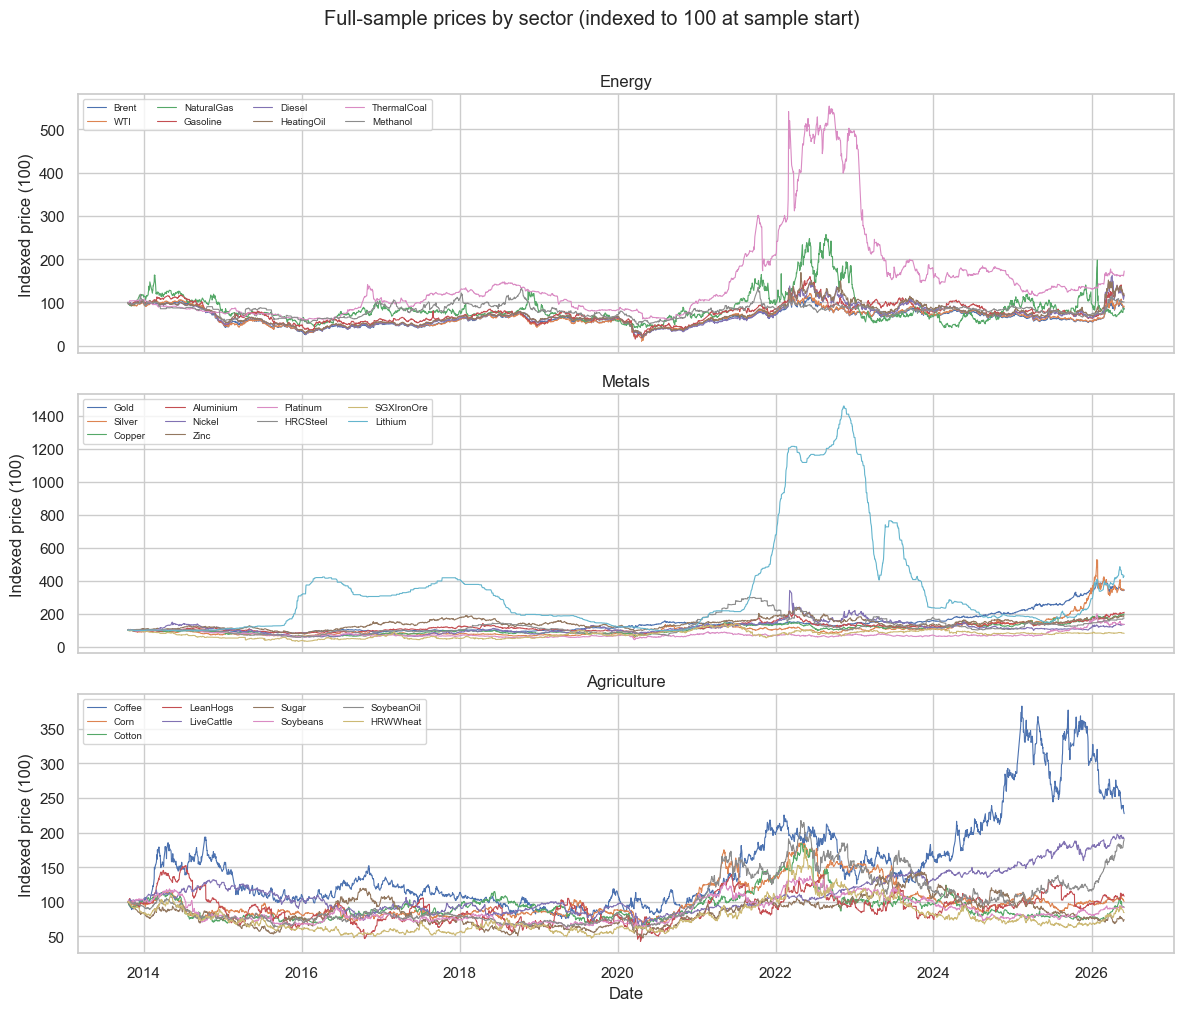

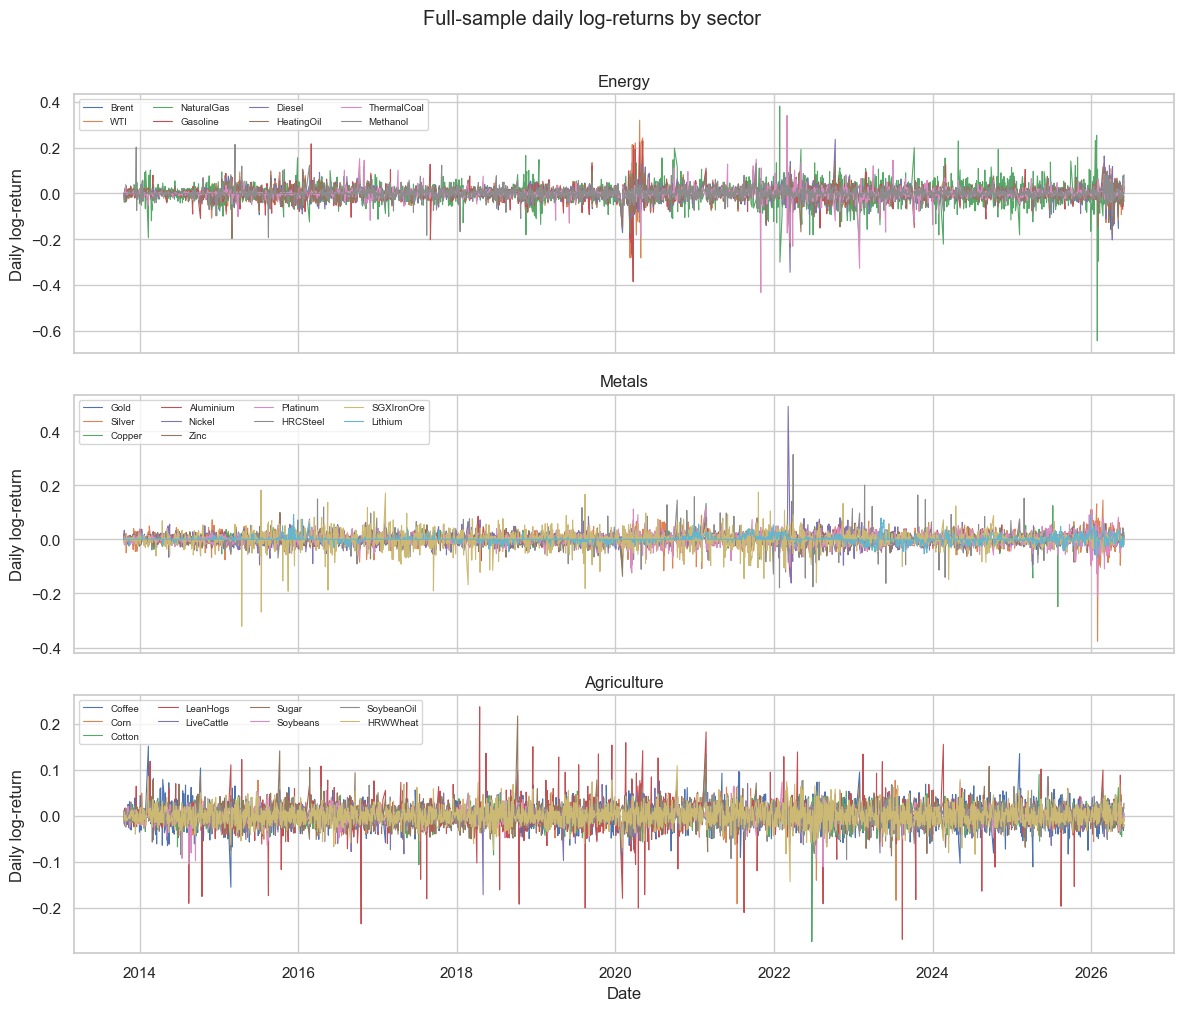

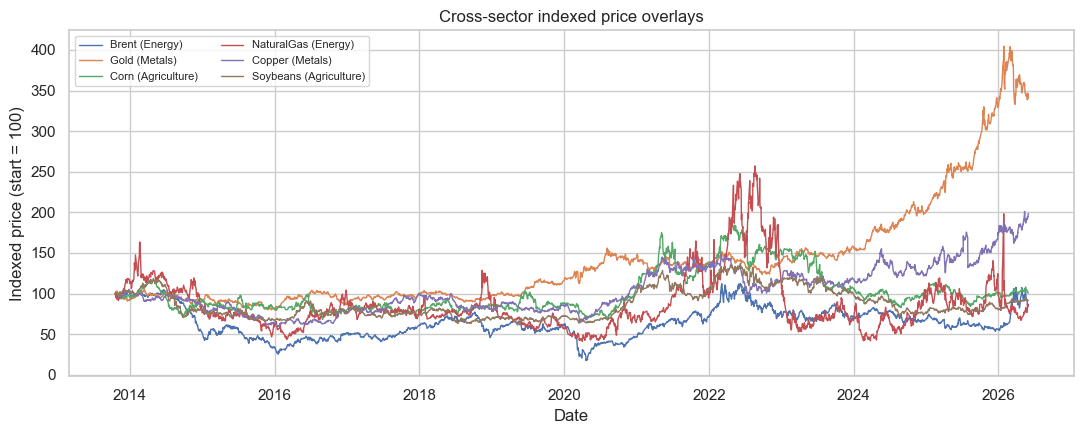

In [4]:
def plot_sector_multiples(data, ylabel, title, indexed=False):
    fig, axes = plt.subplots(len(SECTOR_ORDER), 1, figsize=(12, 10), sharex=True)
    for ax, sector in zip(axes, SECTOR_ORDER):
        cols = [c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]
        for c in cols:
            series = data[c]
            if indexed:
                series = series / series.iloc[0] * 100
            ax.plot(series.index, series.values, lw=0.8, label=c)
        ax.set_ylabel(ylabel)
        ax.set_title(sector)
        ax.legend(ncol=4, fontsize=7, loc="upper left")
    axes[-1].set_xlabel("Date")
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

plot_sector_multiples(prices, "Indexed price (100)", "Full-sample prices by sector (indexed to 100 at sample start)", indexed=True)
plot_sector_multiples(log_returns, "Daily log-return", "Full-sample daily log-returns by sector")

overlay_specs = [
    ("Brent", "Energy"),
    ("Gold", "Metals"),
    ("Corn", "Agriculture"),
    ("NaturalGas", "Energy"),
    ("Copper", "Metals"),
    ("Soybeans", "Agriculture"),
]
fig, ax = plt.subplots(figsize=(11, 4.5))
for c, sector in overlay_specs:
    idx = prices[c] / prices[c].iloc[0] * 100
    ax.plot(idx.index, idx.values, lw=1.0, label=f"{c} ({sector})")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed price (start = 100)")
ax.set_title("Cross-sector indexed price overlays")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


**Takeaway:** Long-run price and return paths cluster by sector, while cross-sector overlays show periods when energy, metals, and agriculture diverge.


## 3. Volatility


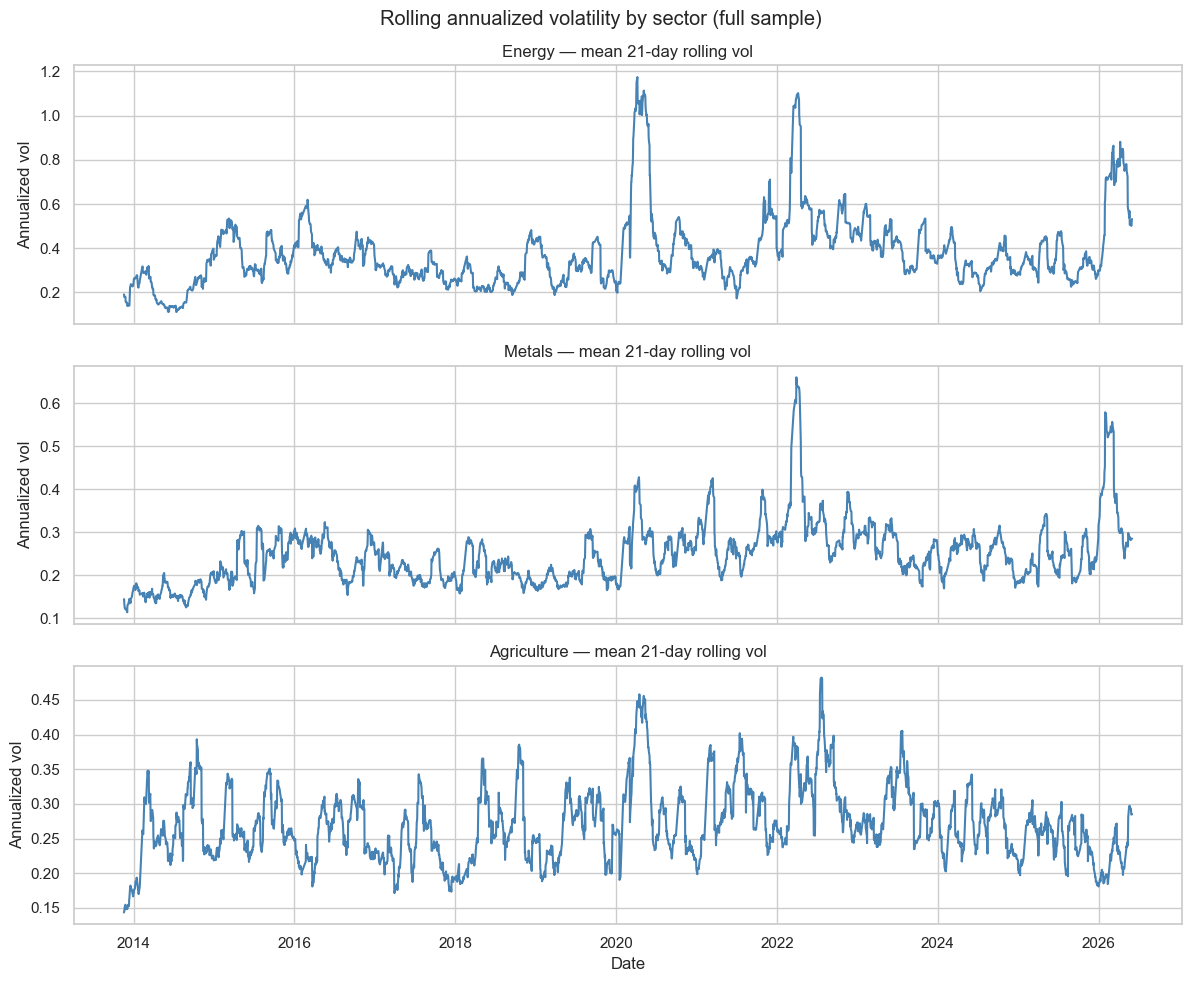

,sector,ann_vol
NaturalGas,Energy,0.6870
WTI,Energy,0.4739
Gasoline,Energy,0.4564
SGXIronOre,Metals,0.4462
LeanHogs,Agriculture,0.4358
Diesel,Energy,0.4117
Brent,Energy,0.4085
HeatingOil,Energy,0.3997
Coffee,Agriculture,0.3684
ThermalCoal,Energy,0.3621


In [5]:
def annualized_vol(returns, window=ROLLING_VOL_WINDOW):
    return returns.rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)

roll_vol = annualized_vol(log_returns)

fig, axes = plt.subplots(len(SECTOR_ORDER), 1, figsize=(12, 10), sharex=True)
for ax, sector in zip(axes, SECTOR_ORDER):
    cols = [c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]
    ax.plot(roll_vol[cols].mean(axis=1).index, roll_vol[cols].mean(axis=1).values, color="steelblue")
    ax.set_ylabel("Annualized vol")
    ax.set_title(f"{sector} — mean {ROLLING_VOL_WINDOW}-day rolling vol")
axes[-1].set_xlabel("Date")
fig.suptitle("Rolling annualized volatility by sector (full sample)")
plt.tight_layout()
plt.show()

full_vol = log_returns.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
vol_table = pd.DataFrame({
    "sector":        full_vol.index.map(SECTOR_MAP),
    "ann_vol":       full_vol,
}).sort_values("ann_vol", ascending=False)
display(vol_table.round(4))

**Takeaway:** Full-sample annualised volatility ranks commodities by risk level over the complete 2013–2026 window. Energy and metals tend to be the most volatile; livestock and precious metals the least.

## 4. Correlation / co-movement


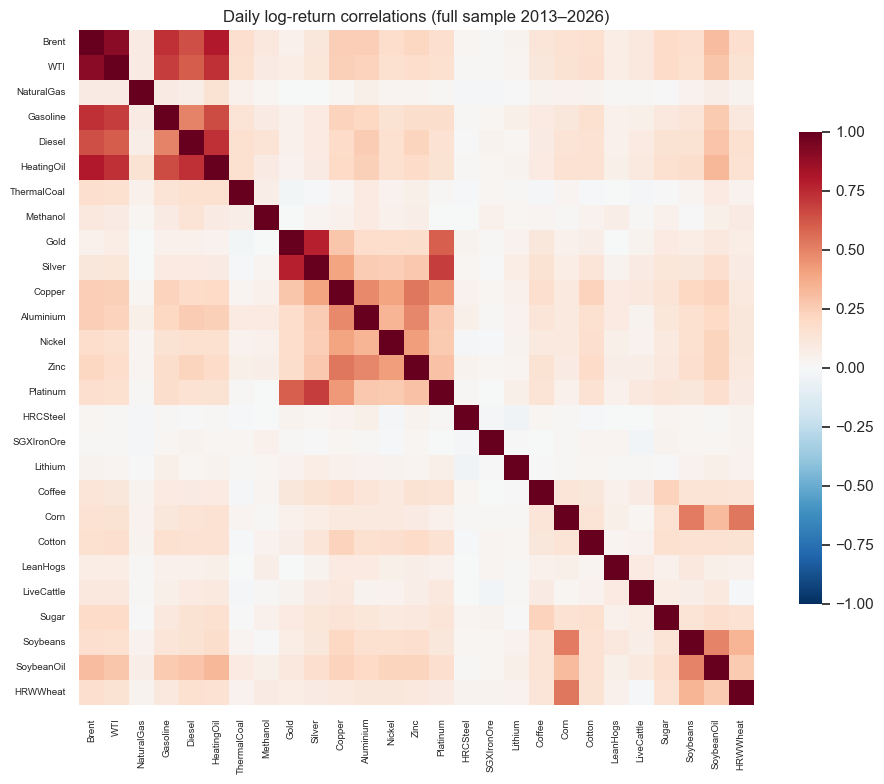

In [6]:
def sector_ordered_corr(df):
    ordered = [c for c in COMMODITIES_ORDERED if c in df.columns]
    return df[ordered].corr()

corr_full = sector_ordered_corr(log_returns)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_full, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={"shrink": 0.7},
    xticklabels=corr_full.columns, yticklabels=corr_full.columns,
)
ax.set_title("Daily log-return correlations (full sample 2013–2026)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

**Takeaway:** Within-sector correlations (Energy, Metals, Agriculture) are clearly visible as blocks. Cross-sector pairs with high correlation are candidates for shared latent factors the autoencoder should capture.

## 5. Recent deep dive & event detection


Cumulative log-return (2013-10-21 → 2026-06-01):


,sector,cumulative_log_return
Lithium,Metals,1.4541
Silver,Metals,1.2616
Gold,Metals,1.2317
Coffee,Agriculture,0.8778
Aluminium,Metals,0.7447
Copper,Metals,0.7365
LiveCattle,Agriculture,0.6836
SoybeanOil,Agriculture,0.6770
Zinc,Metals,0.6496
ThermalCoal,Energy,0.5578



Equal-weight sector cumulative log-return:


,cumulative_log_return
Metals,0.7038
Energy,0.3073
Agriculture,0.1757


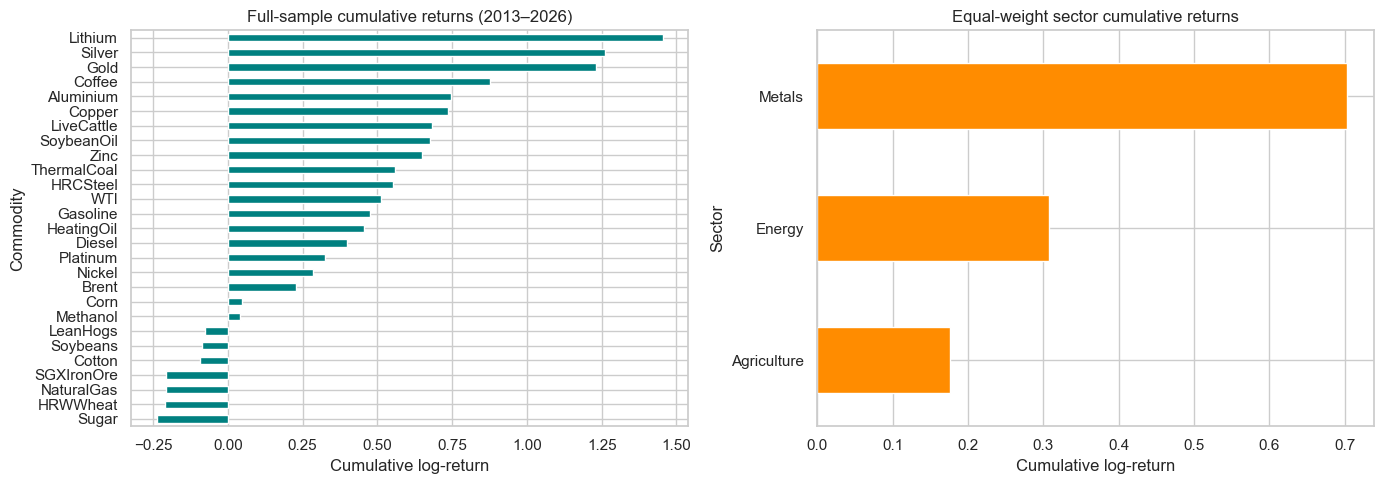


Wrote 1105 events → ../data/market_events.csv


,date,commodity,sector,return,sigma_level,signature
0,2013-12-16,Methanol,Energy,0.202144,9.90,+9.9σ daily move
1,2013-12-18,Methanol,Energy,-0.074021,-3.62,−3.6σ daily move
2,2013-12-19,Gold,Metals,-0.033815,-3.20,−3.2σ daily move
3,2014-01-10,Corn,Agriculture,0.049137,3.01,+3.0σ daily move
4,2014-02-10,Coffee,Agriculture,0.151096,6.51,+6.5σ daily move
...,...,...,...,...,...,...
1100,2026-06-01,Soybeans/SoybeanOil,Agriculture-Agriculture,0.499887,NaN,high correlation (ρ=+0.50)
1101,2026-06-01,WTI,Energy,NaN,NaN,vol spike (1.52× full-sample)
1102,2026-06-01,WTI/Diesel,Energy-Energy,0.602444,NaN,high correlation (ρ=+0.60)
1103,2026-06-01,WTI/Gasoline,Energy-Energy,0.687923,NaN,high correlation (ρ=+0.69)


In [7]:
cum_returns = log_returns.sum().sort_values(ascending=False)
cum_df = cum_returns.to_frame("cumulative_log_return")
cum_df.insert(0, "sector", cum_df.index.map(SECTOR_MAP))
print(f"Cumulative log-return ({log_returns.index.min().date()} → {log_returns.index.max().date()}):")
display(cum_df.round(4))

sector_cum = pd.Series({
    sector: log_returns[[c for c in COMMODITIES if SECTOR_MAP[c] == sector]].mean(axis=1).sum()
    for sector in SECTOR_ORDER
}).sort_values(ascending=False)
print("\nEqual-weight sector cumulative log-return:")
display(sector_cum.to_frame("cumulative_log_return").round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cum_returns.sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_xlabel("Cumulative log-return")
axes[0].set_ylabel("Commodity")
axes[0].set_title("Full-sample cumulative returns (2013–2026)")
sector_cum.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_xlabel("Cumulative log-return")
axes[1].set_ylabel("Sector")
axes[1].set_title("Equal-weight sector cumulative returns")
plt.tight_layout()
plt.show()

# --- Detect sigma events over the full sample and write handoff file ---
full_sigma = log_returns.std(ddof=0)
events = []

for date, row in log_returns.iterrows():
    for commodity in COMMODITIES:
        r = row[commodity]
        sig = full_sigma[commodity]
        if sig == 0 or np.isnan(r):
            continue
        z = r / sig
        if abs(z) >= SIGMA_EVENT_THRESHOLD:
            sign = "−" if z < 0 else "+"
            events.append({
                "date": date.date().isoformat(),
                "commodity": commodity,
                "sector": SECTOR_MAP[commodity],
                "return": r,
                "sigma_level": round(z, 2),
                "signature": f"{sign}{abs(z):.1f}σ daily move",
            })

for commodity in COMMODITIES:
    roll_ratio = (
        log_returns[commodity].rolling(21).std().iloc[-1] /
        (full_sigma[commodity] + 1e-12)
    )
    if roll_ratio >= VOL_SPIKE_RATIO:
        events.append({
            "date": log_returns.index.max().date().isoformat(),
            "commodity": commodity,
            "sector": SECTOR_MAP[commodity],
            "return": np.nan,
            "sigma_level": np.nan,
            "signature": f"vol spike ({roll_ratio:.2f}× full-sample)",
        })

cols = list(corr_full.columns)
for i, c1 in enumerate(cols):
    for c2 in cols[i + 1:]:
        delta = corr_full.loc[c1, c2]
        if abs(delta) >= CORR_BREAK_THRESHOLD:
            events.append({
                "date": log_returns.index.max().date().isoformat(),
                "commodity": f"{c1}/{c2}",
                "sector": f"{SECTOR_MAP[c1]}-{SECTOR_MAP[c2]}",
                "return": delta,
                "sigma_level": np.nan,
                "signature": f"high correlation (ρ={delta:+.2f})",
            })

events_df = pd.DataFrame(events, columns=["date", "commodity", "sector", "return", "sigma_level", "signature"])
if not events_df.empty:
    events_df = events_df.sort_values(["date", "commodity"]).reset_index(drop=True)

events_df.to_csv(EVENTS_PATH, index=False)
print(f"\nWrote {len(events_df)} events → {EVENTS_PATH}")
display(events_df)

**Takeaway:** Sigma events (|r| > 3σ), recent vol spikes, and high correlations are exported to `data/market_events.csv` for downstream analysis.